In [1]:
import pandas as pd
seeds = pd.read_csv(r'C:\Users\Tharun37\OneDrive\Desktop\ms ml\seeds.csv', delimiter = ",", header = 'infer')
print(seeds.head())

    area  perimeter  compactness  kernel_length  kernel_width  \
0  15.26      14.84       0.8710          5.763         3.312   
1  14.88      14.57       0.8811          5.554         3.333   
2  14.29      14.09       0.9050          5.291         3.337   
3  13.84      13.94       0.8955          5.324         3.379   
4  16.14      14.99       0.9034          5.658         3.562   

   asymmetry_coefficient  groove_length  species  
0                  2.221          5.220        0  
1                  1.018          4.956        0  
2                  2.699          4.825        0  
3                  2.259          4.805        0  
4                  1.355          5.175        0  


In [3]:
features = seeds[seeds.columns[0:6]]
print(features.sample(10))

      area  perimeter  compactness  kernel_length  kernel_width  \
4    16.14      14.99       0.9034          5.658         3.562   
1    14.88      14.57       0.8811          5.554         3.333   
206  11.23      12.88       0.8511          5.140         2.795   
169  11.24      13.00       0.8359          5.090         2.715   
5    14.38      14.21       0.8951          5.386         3.312   
144  11.82      13.40       0.8274          5.314         2.777   
204  12.37      13.47       0.8567          5.204         2.960   
198  12.62      13.67       0.8481          5.410         2.911   
120  20.24      16.91       0.8897          6.315         3.962   
127  17.98      15.85       0.8993          5.979         3.687   

     asymmetry_coefficient  
4                    1.355  
1                    1.018  
206                  4.325  
169                  3.521  
5                    2.462  
144                  4.471  
204                  3.919  
198                  3.306  
1

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

scaled_features = MinMaxScaler().fit_transform(features[seeds.columns[0:6]])
pca = PCA(n_components = 2).fit(scaled_features)
features_2d = pca.transform(scaled_features)
print(features_2d[0:10])

[[ 0.11883593 -0.09382469]
 [ 0.0696878  -0.31077233]
 [-0.03499184 -0.37044705]
 [-0.06582089 -0.36365235]
 [ 0.32594892 -0.37695797]
 [-0.02455447 -0.31060184]
 [-0.00769646 -0.07594931]
 [-0.05646955 -0.26696284]
 [ 0.38196305 -0.05149471]
 [ 0.35701044 -0.17697998]]


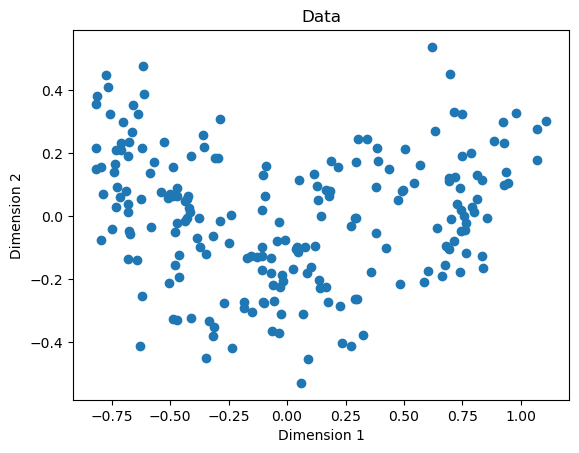

In [8]:
import matplotlib.pyplot as plt
plt.scatter(features_2d[:,0], features_2d[:,1])
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("Data")
plt.show()

C:\Users\Tharun37\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tharun37\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tharun37\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Tharun37\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

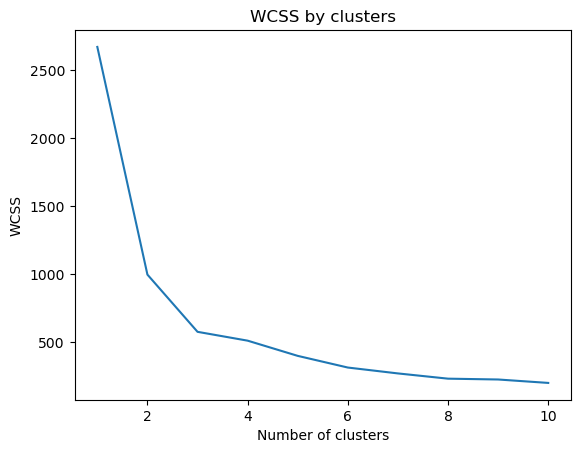

In [9]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i)
    kmeans.fit(features.values)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('WCSS by clusters')
plt.xlabel('Number of clusters')
plt.ylabel("WCSS")
plt.show()